In [1]:
# DS4400 HW 3
# Eunchae Hong
# Problem 3: Comparing Classifiers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_curve, auc
)
from sklearn.neighbors import KNeighborsClassifier

# load the spam database in and implement the same train test split
spam_data = pd.read_csv("spambase/spambase.data", header = None)
X = spam_data.iloc[:, :-1].values
y = spam_data.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state = 5
)

In [2]:
# make a function to report metrics for the classifiers
def report_metrics(label, y_true, y_pred):
    accuracy  = accuracy_score(y_true, y_pred)
    error = 1 - accuracy
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    print(f"{label}")
    print(f"Accuracy: {round(accuracy, 3)} Error: {round(error, 3)}\nPrecision: {round(precision, 3)} Recall: {round(recall, 3)}")

In [3]:
'''
    Part 1
    Use cross-validation to select the $k$ hyper-parameter for kNN.
    Show the accuracy, error, precision, and recall metrics on the validation dataset for multiple values of $k$.
    Select the value of $k$ that minimizes the average cross validation error.
'''
k_vals = [1, 3, 15, 33]
cross_val_errors = {}

# print the accuracy, error, precision, and recall metrics on the validation dataset
for val in k_vals:
    knn = KNeighborsClassifier(n_neighbors = val)
    cross_val_scores = cross_val_score(knn, X_train, y_train, cv = 5, scoring = "accuracy")
    cross_val_error = 1 - cross_val_scores.mean()
    cross_val_errors[val] = cross_val_error
    print(f"k = {val}\nAccuracy: {round(cross_val_scores.mean(), 3)} Error: {round(cross_val_error, 3)}"
          f" Precision: {round(cross_val_score(knn, X_train, y_train, cv = 5, scoring = 'precision').mean(), 3)}"
          f" Recall: {round(cross_val_score(knn, X_train, y_train, cv = 5, scoring = 'recall').mean(), 3)}")

# choose the value of k that minimizes the cross validation error
best_k = min(cross_val_errors, key = cross_val_errors.get)
print(f"The value of k that minimizes the average cross validation error is: {best_k}")

k = 1
Accuracy: 0.794 Error: 0.206 Precision: 0.739 Recall: 0.743
k = 3
Accuracy: 0.787 Error: 0.213 Precision: 0.742 Recall: 0.712
k = 15
Accuracy: 0.762 Error: 0.238 Precision: 0.709 Recall: 0.681
k = 33
Accuracy: 0.75 Error: 0.25 Precision: 0.698 Recall: 0.655
The value of k that minimizes the average cross validation error is: 1


In [ ]:
'''
    Part 2
    Print the accuracy, error, precision, and recall metrics for all 3 classifiers on both training and testing data.
    Which model is performing best?
    Which one is performing worst? Write down some observations (answered in the text box below)
'''
# train the three classifiers
logit_model = LogisticRegression(max_iter = 10000, solver = "lbfgs", random_state = 5)
lda_model = LinearDiscriminantAnalysis()
knn_model = KNeighborsClassifier(n_neighbors = best_k)

logit_model.fit(X_train, y_train)
lda_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

# print metrics for the three classifiers on training and testing data
for name, model in [("Logistic Regression", logit_model), ("LDA", lda_model), ("KNN", knn_model)]:
    report_metrics(f"{name} Training Metrics", y_train, model.predict(X_train))
    report_metrics(f"{name} Testing Metrics", y_test, model.predict(X_test))

Logistic Regression Traning Metrics
Accuracy: 0.93 Error: 0.07
Precision: 0.929 Recall: 0.891
Logistic Regression Testing Metrics
Accuracy: 0.929 Error: 0.071
Precision: 0.917 Recall: 0.896
LDA Traning Metrics
Accuracy: 0.885 Error: 0.115
Precision: 0.92 Recall: 0.777
LDA Testing Metrics
Accuracy: 0.893 Error: 0.107
Precision: 0.912 Recall: 0.799
KNN Traning Metrics
Accuracy: 0.999 Error: 0.001
Precision: 0.999 Recall: 0.999
KNN Testing Metrics
Accuracy: 0.831 Error: 0.169
Precision: 0.772 Recall: 0.797


***Part 2 Questions: Which model is performing best? Which one is performing worst? Write down some observations.***

The model that is performing the best is the **Logistic Regression** model has the highest metrics on the testing set - accuracy of 0.929, precision of 0.917, and recall of 0.896, making it the best model. The model that is performing the worst is **KNN** as it has the lowest metrics on the testing set - accuracy of 0.831, precision of 0.772, and recall of 0.797. Additionally, the metrics for testing and training in KNN show a significant difference,that may be attributed to overfitting.

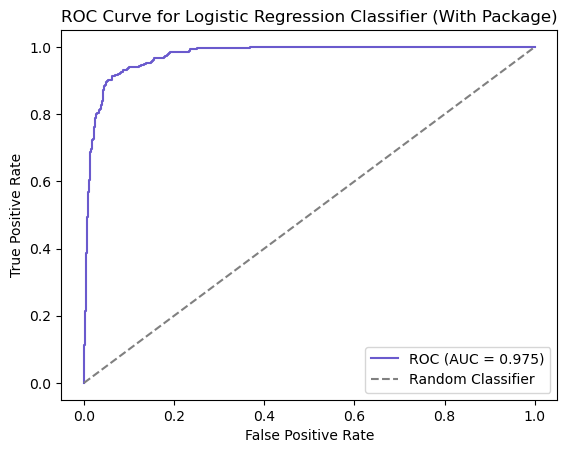

In [5]:
'''
    Part 3
    Generate a graph that includes ROC curve for the logistic regression classifier on the testing set. 
    Compute the Area Under the Curve (AUC) metric. You can use a package for this.
'''
y_prob = logit_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc (fpr, tpr)

plt.plot(fpr, tpr, color = "slateblue", label = f"ROC (AUC = {round(roc_auc, 3)})")
plt.plot([0, 1], [0, 1], color = "gray", linestyle = "--", label = "Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression Classifier (With Package)")
plt.legend()
plt.show()

Threshold: 0
FPR: 1.0 TPR: 1.0
Threshold: 0.1
FPR: 0.305 TPR: 0.995
Threshold: 0.2
FPR: 0.185 TPR: 0.975
Threshold: 0.3
FPR: 0.12 TPR: 0.941
Threshold: 0.4
FPR: 0.072 TPR: 0.916
Threshold: 0.5
FPR: 0.051 TPR: 0.896
Threshold: 0.6
FPR: 0.042 TPR: 0.847
Threshold: 0.7
FPR: 0.027 TPR: 0.799
Threshold: 0.8
FPR: 0.021 TPR: 0.736
Threshold: 0.9
FPR: 0.013 TPR: 0.628
Threshold: 1
FPR: 0.0 TPR: 0.0


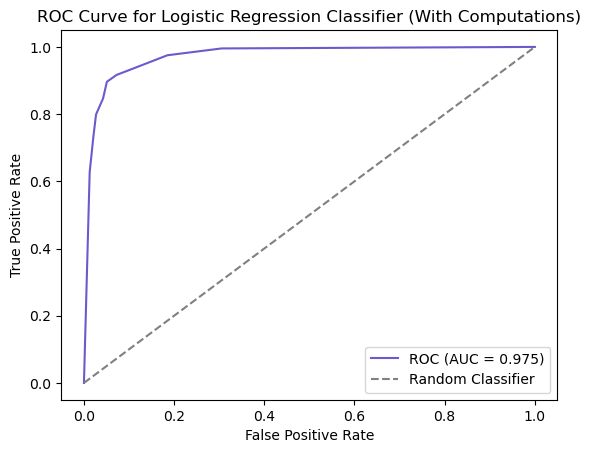

In [6]:
'''
    Part 4
    Write code to plot a ROC curve without a package for logistic regression.
    Vary the prediction threshold T{0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1\}, and compute false positive and true positive rates for each threshold.
    Plot a ROC curve for these points, and compare it with the ROC curve generated with the package in part (3).
    What are the differences and what changes can you make to get the two ROC curves to become more similar? (answered in the text box below)
'''
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
comp_fpr = []
comp_tpr = []

# compute the tp and fp for each threshold
for num in thresholds:
    y_pred_T = (y_prob >= num).astype(int)
    tp = np.sum((y_pred_T == 1) & (y_test == 1))
    fp = np.sum((y_pred_T == 1) & (y_test == 0))
    tn = np.sum((y_pred_T == 0) & (y_test == 0))
    fn = np.sum((y_pred_T == 0) & (y_test == 1))

    if (tp + fn) > 0:
        tpr_val = tp / (tp + fn)
    else:
        tpr_val = 0

    if (fp + tn) > 0:
        fpr_val = fp / (fp + tn)
    else:
        fpr_val = 0

    comp_tpr.append(tpr_val)
    comp_fpr.append(fpr_val)
    print(f"Threshold: {num}\nFPR: {round(fpr_val, 3)} TPR: {round(tpr_val, 3)}")

# plot the graph
plt.plot(comp_fpr, comp_tpr, color = "slateblue", label = f"ROC (AUC = {round(roc_auc, 3)})")
plt.plot([0, 1], [0, 1], color = "gray", linestyle = "--", label = "Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression Classifier (With Computations)")
plt.legend()
plt.show()


***Part 3 Questions: What are the differences and what changes can you make to get the two ROC curves to become more similar?***

The curve made with the package is much smoother as there are more points plotted compared to the curve that uses the computatons since it only considers 11 different thresholds making it look more stiff. However, both curves have the same ROC (AUC) of 0.975. To make the curves more similar I would add more threshold values to the curve with the computations, so that the curve is less stiff and starts to look more like the one with created with the package. 